In [25]:
gpu = False # make sure this matches in the other files
if gpu:
    print('using gpu')
    import cupy as np
    from cupyx.scipy import sparse
    def njit(fastmath=0): # have to write a wrapper that does nothing for GPU compatibility. 
        def decorator(func):
            def wrapper(*args, **kwargs):
                return func(*args, **kwargs)
            return wrapper
        return decorator
else:
    print('not using gpu')
    import numpy as np
    from scipy import sparse
    from numba import njit
    from scipy.sparse.linalg import splu

pi = np.pi
norm = np.linalg.norm
from matplotlib import pyplot as plt

not using gpu


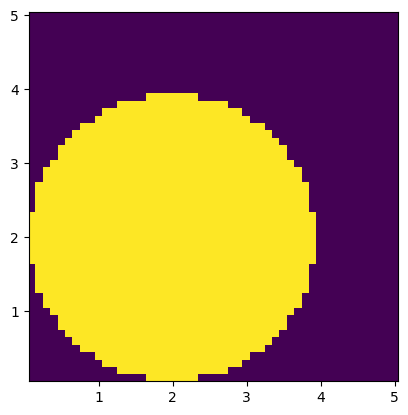

In [37]:
def is_interior_vec(grid_pts, params):
    shape = params[-1]
    if shape==0:
        x0 = np.array([params[0],params[1],params[2]])
        r = params[3]
        dists = np.sqrt(((grid_pts - x0)**2).sum(axis=1))
        return dists < r
    elif shape==1:
        x0 = np.array([params[0],params[1],params[1]*0])
        h = params[2]
        r = params[3]
        return ((grid_pts[:,2]<h) & (norm(np.stack([
            grid_pts[:,0],grid_pts[:,1],grid_pts[:,1]*0
            ],axis=1) - x0, axis=1) < r)) | ((grid_pts[:,2] >= h) & (norm(grid_pts-np.array([params[0],params[1],params[2]]),axis=1)<r) )
    
def cheb(N):
    x = np.cos(pi*np.arange(N+1)/N)
    c = np.concatenate([np.array([2]), np.ones(N-1), np.array([2])])*np.power(-1,np.arange(N+1))
    X = np.transpose(np.tile(x,[N+1,1]))
    dX = X - np.transpose(X)
    D = np.outer(c, 1/c) / (dX + np.eye(N+1))
    D = D - np.diag(np.sum(np.transpose(D), axis=0))
    return D,x
    
r = 2
h = 4
dx = .1
Lx = 5
Ly = 5
Lz = 8
params = np.array([2,2,h,r,1])

Nx = int(np.round(Lx / dx))
if Nx%2:
    Nx = Nx+1
Ny = int(np.round(Ly / dx))
if Ny%2:
    Ny = Ny+1
Lx = dx*Nx
Ly = dx*Ny
Nz = int(np.round(pi/(np.arcsin(2*dx/Lz))+1)) # this should make the ratio dx/dz close to 1 at the center.
xx = dx*np.arange(1,Nx+1)
yy = dx*np.arange(1,Ny+1)
Dcheb0,zz0 = cheb(Nz-1)
zz = Lz*0.5*(zz0+1)
Dcheb = Dcheb0 / (Lz*0.5)
Y,Z,X = np.meshgrid(yy,zz,xx, indexing='ij')

grid_pts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
interior_mask = is_interior_vec(grid_pts, params)

C = np.ravel(X*0)
C[interior_mask] = 1
C = C.reshape(np.shape(X))

y_slice = params[1]
y_idx = np.argmin(np.abs(yy-y_slice))

z_slice = 4.5
z_idx = np.argmin(np.abs(zz-z_slice))

# plane = C[y_idx,:,:]
# fig, ax = plt.subplots()
# ax.pcolor(xx,zz,plane)
# ax.set_aspect('equal')

plane = C[:,z_idx,:]
fig, ax = plt.subplots()
ax.pcolor(xx,yy,plane)
ax.set_aspect('equal')

In [18]:
import numpy as np
import os
def get_tdesign_points(n):
    if n<=240:
        with open(f'./data/points/des.3.{n}.txt') as text_file:
            surface_points = text_file.read().split('\n')
        surface_points = surface_points[0:-1]
        surface_points = np.array(surface_points, dtype=float)
        surface_points = np.reshape(surface_points, (-1,3))
        
        return(surface_points)
    else:
        with open(f'./data/points/des.3.{n}.txt') as text_file:
            surface_points = text_file.read().split('\n')
        for i,x in enumerate(surface_points):
            pt = x.split(' ')
            pt = np.array([y for y in pt if y != ''])
            surface_points[i] = np.array(pt, dtype=float)
        surface_points = np.array(surface_points[0:-1])
        return(surface_points)

print(os.listdir('./data/points'))
for fname in os.listdir('./data/points'):
    n = int(fname[6:-4])
    surface_points = get_tdesign_points(n)
    np.save(f'./data/points/{n}_tsphere', surface_points)

['des.3.10.txt', 'des.3.100.txt', 'des.3.1038.txt', 'des.3.120.txt', 'des.3.144.txt', 'des.3.180.txt', 'des.3.20.txt', 'des.3.2018.txt', 'des.3.204.txt', 'des.3.240.txt', 'des.3.30.txt', 'des.3.3006.txt', 'des.3.328.txt', 'des.3.40.txt', 'des.3.4008.txt', 'des.3.438.txt', 'des.3.5.txt', 'des.3.50.txt', 'des.3.5154.txt', 'des.3.564.txt', 'des.3.60.txt', 'des.3.6218.txt', 'des.3.70.txt', 'des.3.706.txt', 'des.3.80.txt', 'des.3.864.txt', 'des.3.90.txt']


In [21]:
import cupy as np
x = np.load('./data/points/1038_tsphere.npy')
print(np.shape(x))

(1038, 3)


In [10]:
import os
import numpy as np
v = np.array([],dtype=int)
for fname in os.listdir('./data/points'):
    print(int(fname[:-12]))
    v = np.append(v,int(fname[:-12]))

np.save('./data/points/sphere_number_list',v)

100
1038
10
120
144
180
2018
204
20
240
3006
30
328
4008
40
438
50
5154
564
5
60
6218
706
70
80
864
90


In [ ]:
w = np.load('./data/points/sphere_number_list.npy')
print(w)

[ 100 1038   10  120  144  180 2018  204   20  240 3006   30  328 4008
   40  438   50 5154  564    5   60 6218  706   70   80  864   90]


: 

In [3]:
v = np.arange(10)
v[2]=5
v[v==5]=0
print(v)

[0 1 0 3 4 0 6 7 8 9]


100 100


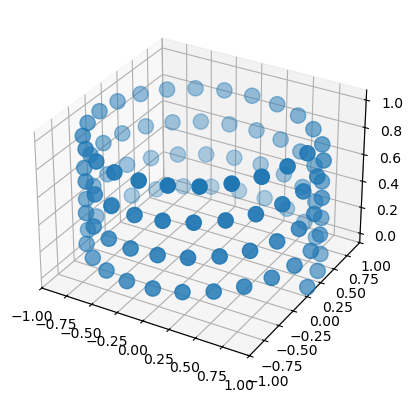

In [22]:
import cupy as np
from matplotlib import pyplot as plt
def get_cylinder_pts(n,h,r):
    # a hollow cylinder, might not be stable at the caps
    # helix method
    nrev = np.sqrt(h*n/(2*pi))
    theta = np.linspace(0,2*pi*nrev,n)
    dh_vec = np.linspace(0,h,n)
    print(len(theta),len(dh_vec))
    pts = np.stack([
        r*np.cos(theta),
        r*np.sin(theta),
        dh_vec
    ], axis=1)
    return pts

n = 100
h = 1
r = 1
pts = get_cylinder_pts(n,h,r).get()
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
# ax.set_xlim([-2,2])
# ax.set_ylim([-2,2])
ax.scatter(pts[:,0],pts[:,1],pts[:,2],s = 120)

In [8]:
import scipy

def BCRows(N):
    '''
    This function gives you the following BCs:
    BCR1 = first derivative (first integral) evaluated at x=1
    BCR2 = function (second integral) evaluated at x=1
    BCL1 = first derivative (first integral) evaluated at x=-1
    BCL2 = NEGATIVE OF function (second integral) evaluated at x=-1
    '''
    BCR1=np.zeros(N+2)
    BCR2=np.zeros(N+2)
    BCL1=np.zeros(N+2)
    BCL2=np.zeros(N+2)
    # Special cases - right 
    BCR1[N+1]=1; BCR2[N+0]=1; BCR1[0]=1; BCR1[2]=-1/2
    BCR2[N+1]=BCR2[N+1]+1; BCR2[1]=-1/8; BCR2[3]=1/8
    BCR1[1]=BCR1[1]+1/4; BCR1[3]=BCR1[3]-1/4; BCR2[0]=BCR2[0]+1/4; BCR2[2]=BCR2[2]-1/8-1/24
    BCR2[4]=BCR2[4]+1/24

    # Special cases - left
    BCL1[N+1]=1; BCL2[N+0]=-1; BCL1[0]=-1; BCL1[2]=1/2
    BCL2[N+1]=BCL2[N+1]+1; BCL2[1]=-1/8; BCL2[3]=1/8
    BCL1[1]=BCL1[1]+1/4; BCL1[3]=BCL1[3]-1/4; BCL2[0]=BCL2[0]-1/4; BCL2[2]=BCL2[2]+1/8+1/24
    BCL2[4]=BCL2[4]-1/24

    # Easy cases
    jj = np.arange(3,N)
    BCR1[jj-1]=BCR1[jj-1]+1/(2*jj) 
    BCL1[jj-1]=BCL1[jj-1]+(-1)**jj/(2*jj)
    BCR1[jj+2-1]=BCR1[jj+2-1]-1/(2*jj)*(jj<N-1) 
    BCL1[jj+2-1]=BCL1[jj+2-1]-(-1)**jj/(2*jj)*(jj<N-1)
    BCR2[jj-1-1]=BCR2[jj-1-1]+1/(2*jj)*1/(2*jj-2) 
    BCL2[jj-1-1]=BCL2[jj-1-1]-1/(2*jj)*1/(2*jj-2)*(-1)**jj
    BCR2[jj+3-1]=BCR2[jj+3-1]+1/(2*jj)*1/(2*jj+2)*(jj<N-2) 
    BCL2[jj+3-1]=BCL2[jj+3-1]-1/(2*jj)*1/(2*jj+2)*(-1)**jj*(jj<N-2)
    BCR2[jj+1-1]=BCR2[jj+1-1]-1/(2*jj)*1/(2*jj-2)-1/(2*jj)*1/(2*jj+2)*(jj<N-1)
    BCL2[jj+1-1]=BCL2[jj+1-1]+(1/(2*jj)*1/(2*jj-2)+1/(2*jj)*1/(2*jj+2)*(jj<N-1))*(-1)**jj
    BCs = np.stack([BCR1, BCR2, BCL1, BCL2])
    return BCs

def SecondIntegralMatrix(N):
    jj = np.arange(3,N)
    colm2 = np.concatenate([np.array([.25]), 1/(2*jj*(2*jj-2)), np.array([0,0]), np.array([0,0])])
    colp2 = np.concatenate([np.array([0,0]), np.array([0, .125, 1/24]), 1/((2*jj)*(2*jj+2))*(jj<N-2)]) # gotta add these extra [0,0]s becaus
    col0 = np.concatenate([np.array([0, -.125, -1/8-1/24]), -1/((2*jj)*(2*jj-2)) - 1/((2*jj)*(2*jj+2))*(jj<N-1), np.array([0,0])] )

    simat = sparse.dia_matrix(([colm2, col0, colp2], np.array([-2,0,2])), (N, N+2), copy=True)
    # simat = simat.tolil(copy=True)
    simat = simat.tocsc()
    simat[0, N+0] = 1
    simat[1,N+1] = 1
    # simat = simat.tocsc()
    return simat


def bvpsolve(f,C,M1,k,H,SIMat):
    Nz = len(f)

    # print(f'shape 1: {np.shape(sparse.diags(np.ones(Nz)))}')
    # print(f'shape 2: {np.shape(k*(H)**2)}')
    # print(f'shape 3: {np.shape(SIMat[0:Nz,0:Nz])}')
    A = sparse.diags(np.ones(Nz)) - k*(H)**2*SIMat[0:Nz,0:Nz]
    A = sparse.csc_matrix(A, dtype=complex)
    Ainv = splu(A)

    M2_solve = Ainv.solve(f)

    M2 = C @ M2_solve -  0 # np.repeat(np.array([0,0]),Nx) because we set 0 penetration on floor and ceiling
    # print(f'shape M1: {np.shape(M1)}')
    # print(f'shape M2: {np.shape(M2)}')
    y = np.linalg.solve(M1,M2)
    By = np.zeros(Nz, dtype=complex)
    By[[0,1]] = -y*k*H**2
    # By_test = bigBy[0:Nz]
    # print(f'err in By: {norm(By - By_test)}')

    x_rhs = f - By
    # x_rhs_test = bigx_rhs_rhs[0:Nz]
    # print(f'err x_rhs: {norm(x_rhs - x_rhs_test)}')

    x = Ainv.solve(x_rhs)
    # x_test = bigx[0:Nz]
    # print(f'err x: {norm(x - x_test)}')
    
    BVPSoln = np.zeros((Nz+2), dtype=complex)
    BVPSoln[0:Nz] = x
    BVPSoln[[Nz,Nz+1]] = y
    return BVPSoln

ksq = 200
Nz = 76
Lz = 12
H = Lz/2
SIMat = SecondIntegralMatrix(Nz)
fhat = np.arange(1,Nz+1) - 1j*np.arange(Nz,0,-1) # for some reason matlab does conjugate transpose

BCs = BCRows(Nz)
BC2 = np.array([BCs[1,:], H*BCs[2,:]]) # BVPChebInt_btmwall_Neumann
BC2_even = np.sqrt(ksq) * H**2 * BCs[1,:] + H*BCs[0,:] - BCs[1,:]
BC2[0] = BC2[0] + BC2_even

C = BC2[:,0:Nz]

B = -H**2 * ksq * SIMat[0:Nz, Nz:(Nz+2)]

A = sparse.diags(np.ones(Nz), dtype=complex) - H**2 * ksq * SIMat[0:Nz,0:Nz]
Ainv = splu(A)
M1_solve = Ainv.solve(B.toarray())
M1 = C @ M1_solve - BC2[:,Nz:(Nz+2)]

secD = bvpsolve(fhat,C,M1,ksq,H,SIMat)
secD_old = scipy.io.loadmat('./data/secD.mat')['secD'].reshape(-1)

print(f'err: {norm(secD - secD_old)}')

err: 9.65016127988013e-12


c:\Users\sedox\miniconda3\envs\sad\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\sedox\AppData\Local\Temp\ipykernel_32848\2445413123.py:108: SparseEfficiencyWarning: splu converted its input to CSC format
  Ainv = splu(A)
